<h4>                                                                                    STUDY OF THE DATASET

In [1]:
#importiamo le librerie di base
import numpy as np 
import pandas as pd 
import librosa.display  # questa sereve per la rappresentazione grafica e gestione di file audio
import matplotlib.pyplot as plt  # serve per calcoli matematic 
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import librosa, IPython

In [2]:
#importiamo il dataset
music_data_3sec = pd.read_csv('Data/features_3_sec.csv') 

music_data_3sec.head(400) #per vedere le prime 5 righe del dataset


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,blues.00039.5.wav,66149,0.254912,0.096668,0.075549,0.001540,927.800980,486582.375961,1507.790608,362042.433117,...,61.430290,-13.859550,41.805470,-11.707463,30.877428,-6.950223,74.613411,-3.268622,57.019863,blues
396,blues.00039.6.wav,66149,0.305514,0.096240,0.074395,0.000461,1637.313387,830627.471679,2105.135391,208222.567268,...,41.758099,-18.315857,79.132271,-7.317917,44.269913,-8.677593,31.230593,-9.824231,62.142185,blues
397,blues.00039.7.wav,66149,0.296374,0.099054,0.068630,0.001324,1003.591629,287729.602578,1615.558460,259439.507721,...,37.480404,-9.156420,37.356796,-11.001587,52.335011,-10.763556,74.891541,-7.393714,75.133080,blues
398,blues.00039.8.wav,66149,0.270586,0.103231,0.148797,0.004121,1834.814057,697989.405657,2223.279025,130237.752710,...,82.259331,-17.886864,81.703011,-7.806378,45.443577,-15.915922,49.487392,-14.522837,45.246620,blues


In [4]:
audio_fp = 'Data/genres_original_3s/blues/blues.00000_segment_0.wav'
audio_data, sr = librosa.load(audio_fp)
audio_data, _ = librosa.effects.trim(audio_data)
IPython.display.Audio(audio_data, rate=sr)


<h3> Studio dei generi musicali 

In [5]:
print("Dataset has",music_data_3sec.shape)
print("Count of Positive and Negative samples")
music_data_3sec.label.value_counts().reset_index()


Dataset has (9990, 60)
Count of Positive and Negative samples


,label,count
0,blues,1000
1,jazz,1000
2,metal,1000
3,pop,1000
4,reggae,1000
5,disco,999
6,classical,998
7,hiphop,998
8,rock,998
9,country,997


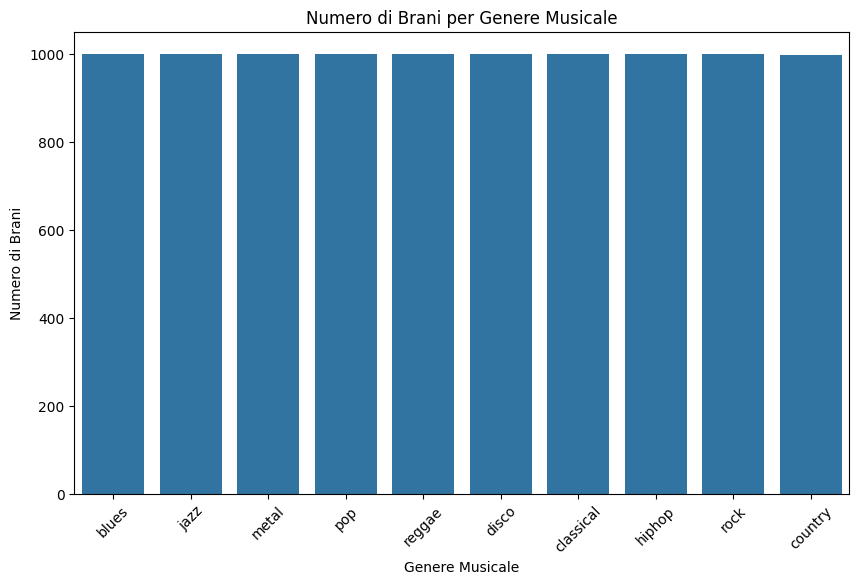

In [6]:
# Contare le occorrenze di ciascun genere e salvarlo in genre_counts

genre_counts = music_data_3sec['label'].value_counts()

# Plot del numero dei tipi musicali
plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.index, y=genre_counts.values)
plt.xlabel("Genere Musicale")
plt.ylabel("Numero di Brani")
plt.title("Numero di Brani per Genere Musicale")
plt.xticks(rotation=45)  # Ruota le etichette per una migliore leggibilità
plt.show()


In [7]:
print("Dataset has",music_data_3sec.shape)
print("Count of Positive and Negative samples")
music_data_3sec.label.value_counts().reset_index()


Dataset has (9990, 60)
Count of Positive and Negative samples


,label,count
0,blues,1000
1,jazz,1000
2,metal,1000
3,pop,1000
4,reggae,1000
5,disco,999
6,classical,998
7,hiphop,998
8,rock,998
9,country,997


<h3> Esempio stampa file wav

blues


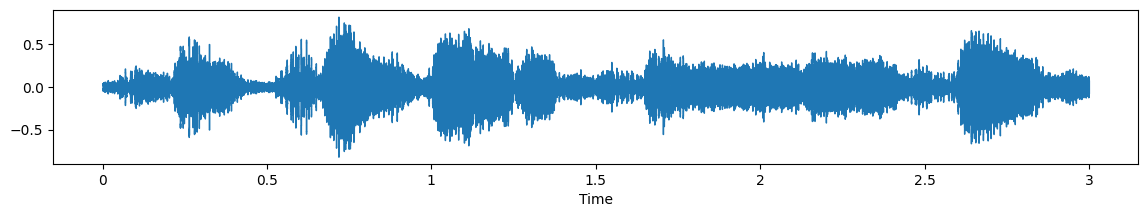

In [8]:
#Stampo la struttura del file audio medio del genere BLUES
path = 'Data/genres_original_3s/blues/blues.00000_segment_0.wav' 
plt.figure(figsize=(14, 2)) 
x, sr = librosa.load(path) 
librosa.display.waveshow(x, sr=sr) 

print("blues")  
  

Pop


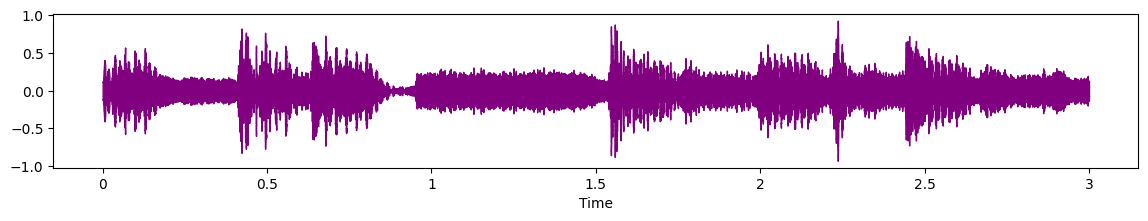

In [9]:
path = 'Data/genres_original_3s/pop/pop.00000_segment_0.wav'
plt.figure(figsize=(14,2)) 
x, sr = librosa.load(path) 
librosa.display.waveshow(x, sr=sr,color='purple')  
print("Pop")


Metal


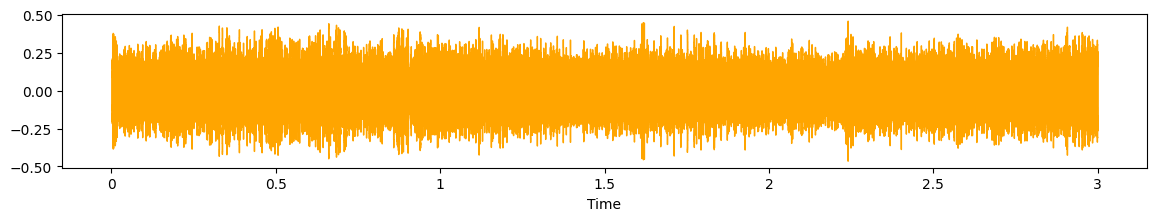

In [10]:
path = 'Data/genres_original_3s/metal/metal.00000_segment_0.wav'
plt.figure(figsize=(14, 2)) 
x, sr = librosa.load(path) 
librosa.display.waveshow(x, sr=sr,color='orange') 
print("Metal")


C:\Users\david\AppData\Local\Temp\ipykernel_23712\3931174226.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = "label", y = "tempo", data = x, palette = 'husl');


Text(0, 0.5, 'BPM')

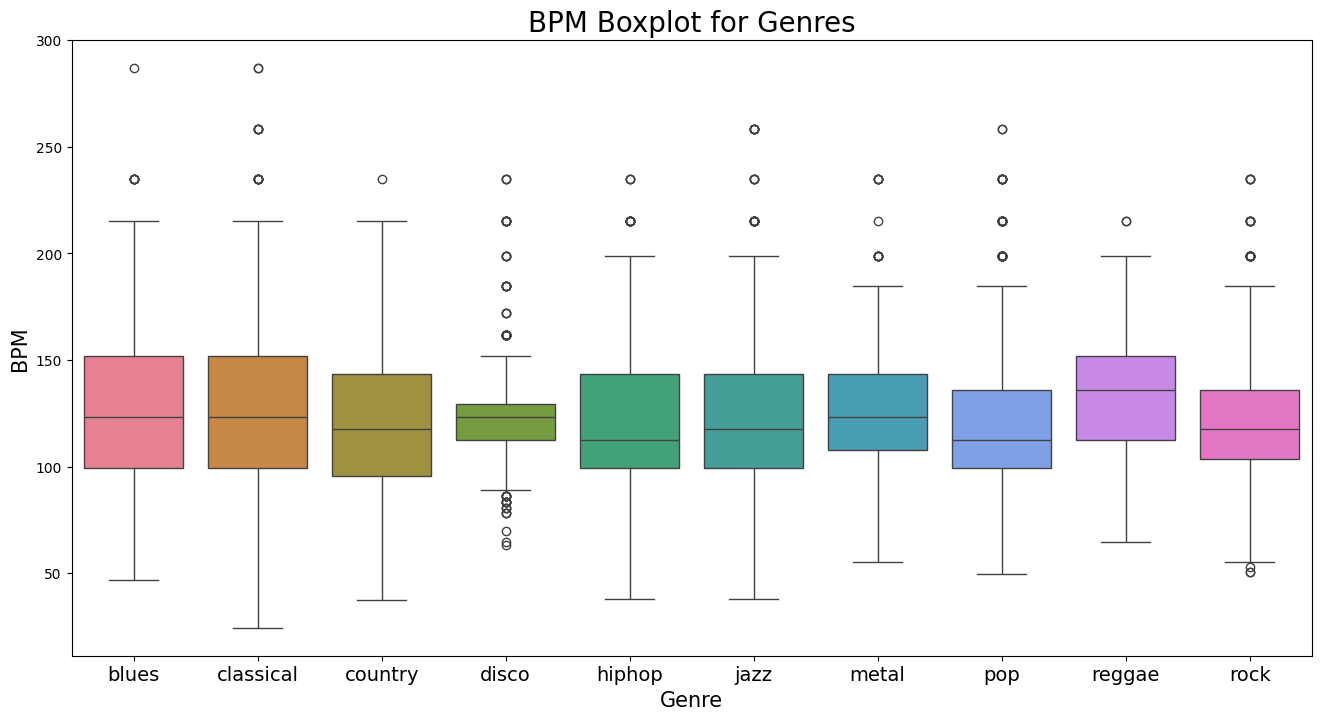

In [11]:
x = music_data_3sec[["label", "tempo"]]

fig, ax = plt.subplots(figsize=(16, 8));
sns.boxplot(x = "label", y = "tempo", data = x, palette = 'husl');

plt.title('BPM Boxplot for Genres', fontsize = 20)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 10);
plt.xlabel("Genre", fontsize = 15)
plt.ylabel("BPM", fontsize = 15)


<h4> MATRICE DI CORRELAZIONE

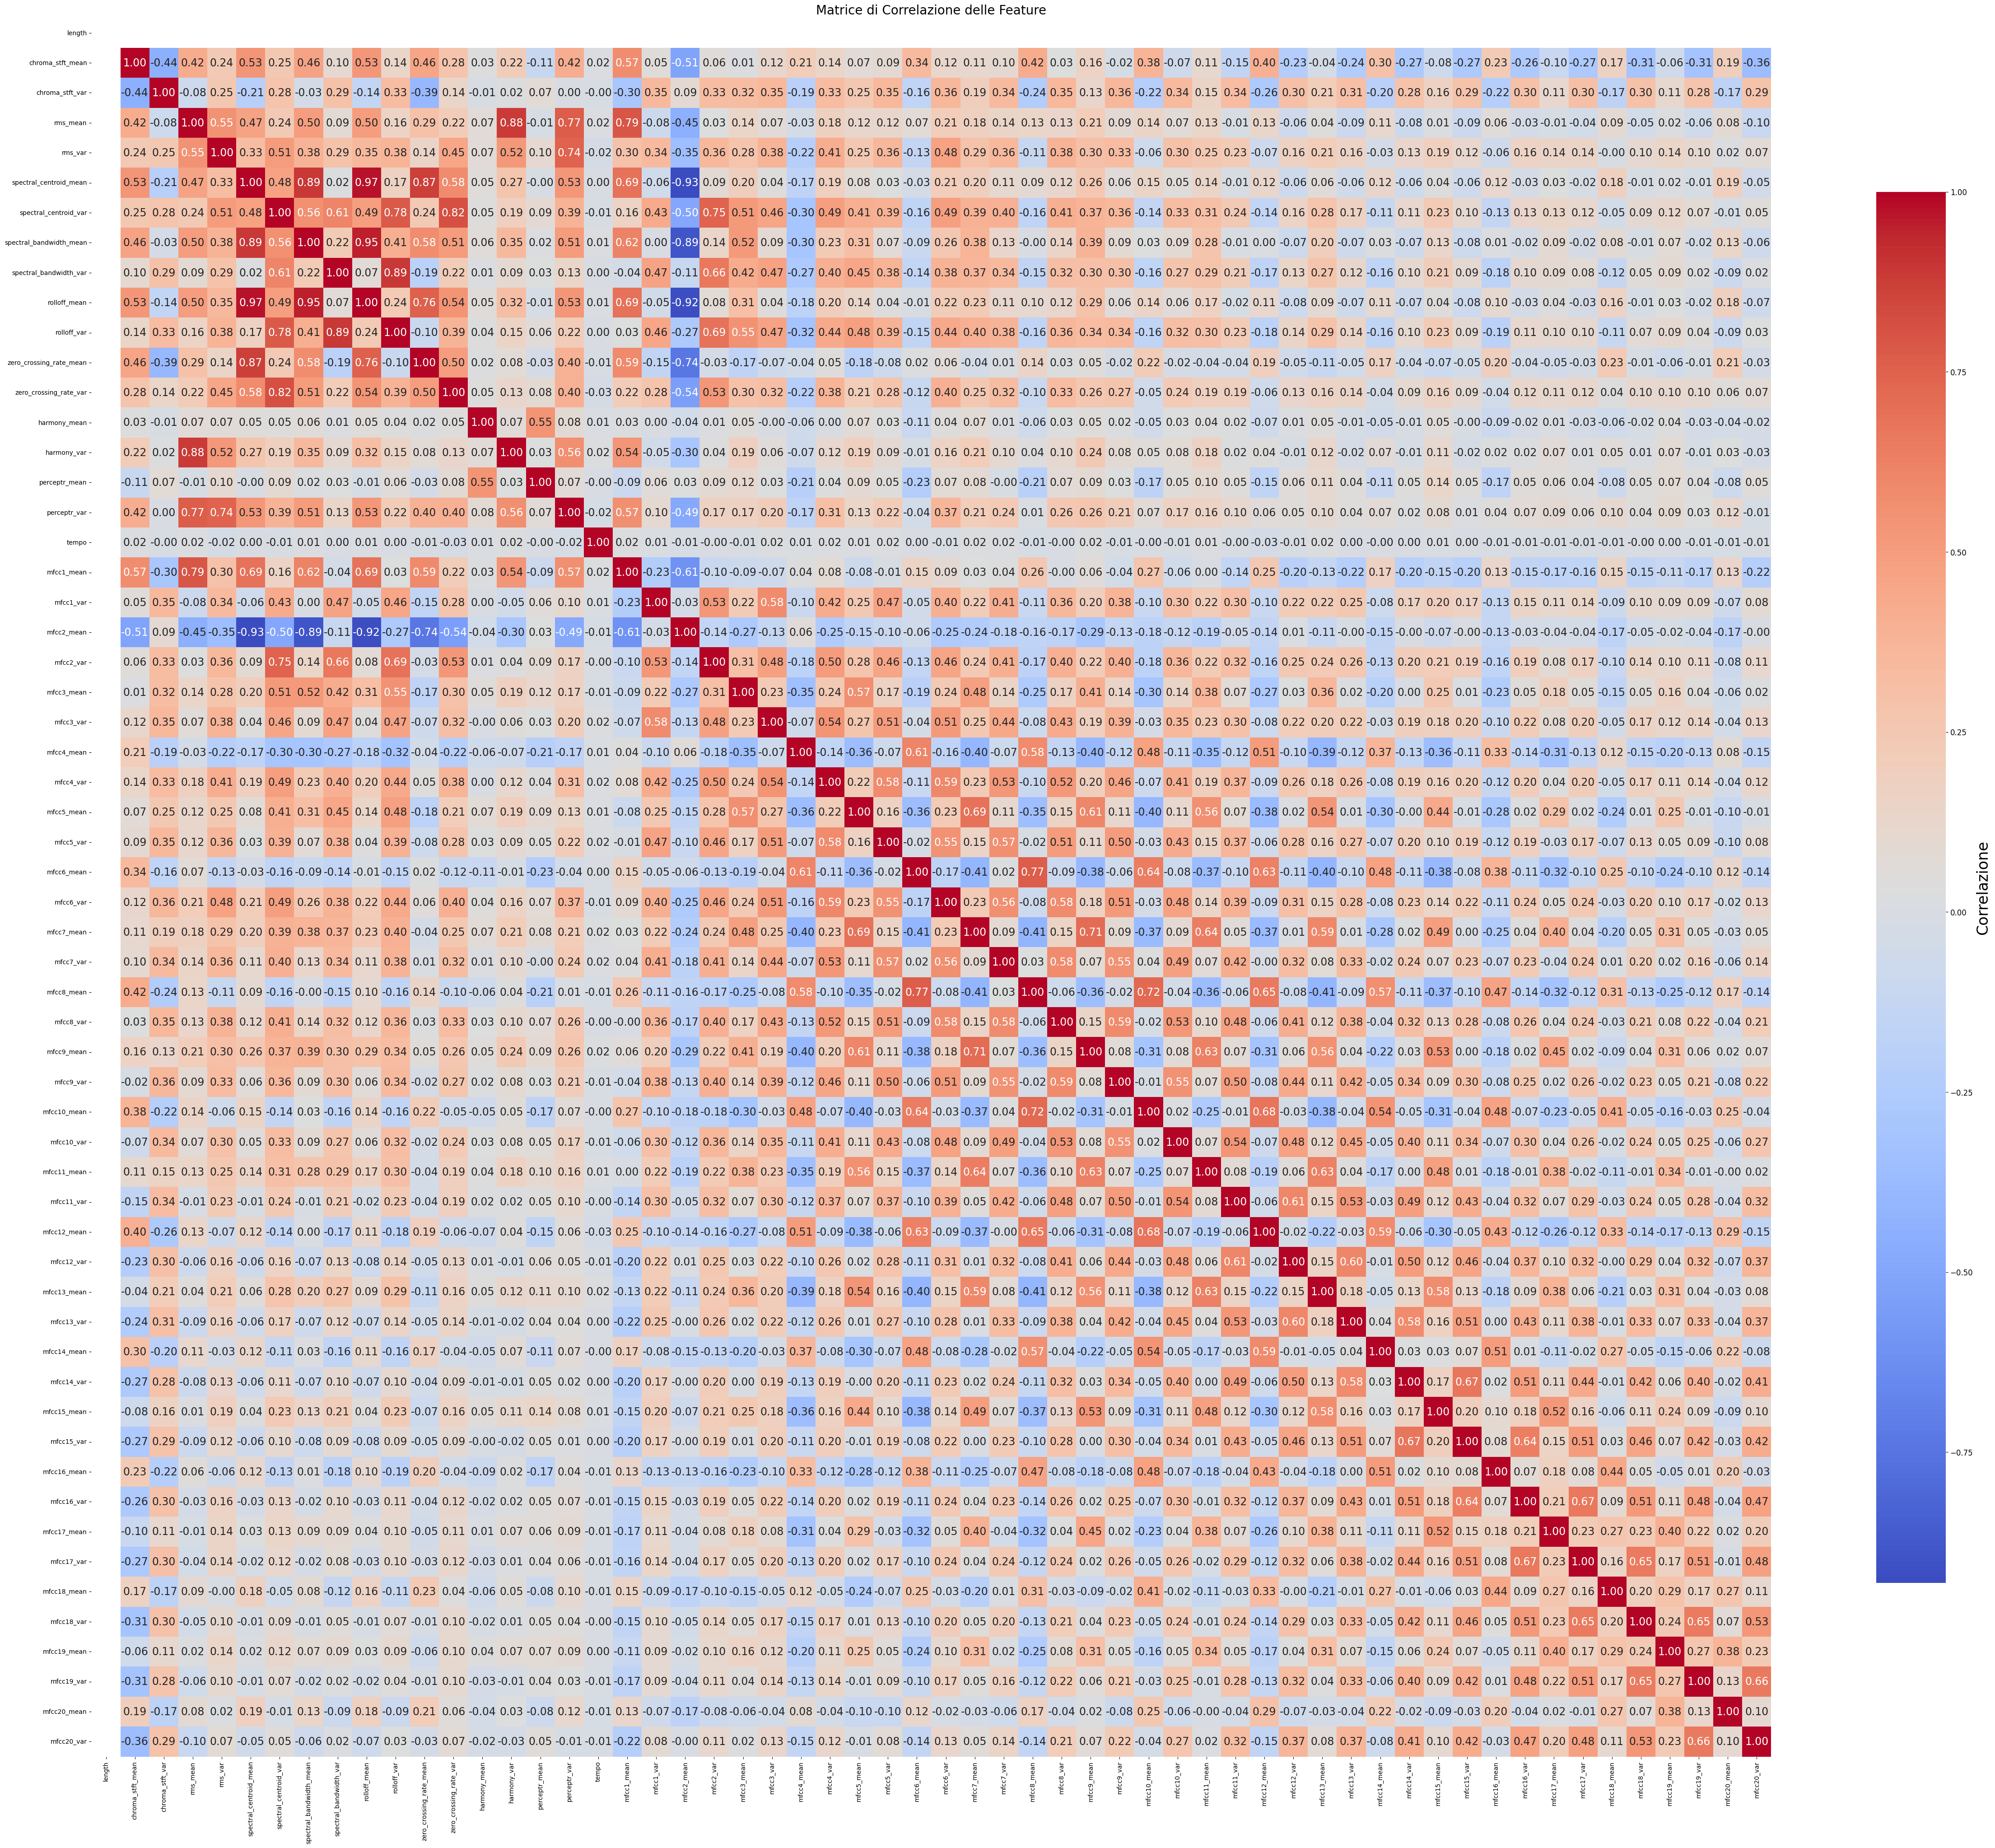

In [12]:
# Rimuovo le colonne non numeriche

X = music_data_3sec.drop(columns=['label', 'filename'])

# Calcola la matrice di correlazione
correlation_matrix = X.corr()

# Configura la dimensione della heatmap
plt.figure(figsize=(60, 50))

# Crea la heatmap
heatmap = sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm',
                       xticklabels=X.columns, yticklabels=X.columns,
                       annot_kws={"size": 17},  # Aumenta la dimensione del font per i valori
                       cbar_kws={"shrink": 0.8, "label": "Correlazione"})  # Rimuovi fontsize da qui


plt.title('Matrice di Correlazione delle Feature', fontsize=20)  # Aumenta la dimensione del titolo
colorbar = heatmap.collections[0].colorbar  # Ottieni il colorbar dalla heatmap
colorbar.ax.tick_params(labelsize=12)  # Aumenta la dimensione del font dei ticks
colorbar.set_label("Correlazione", fontsize=24)  # Imposta il font della label del colorbar
plt.show()


<h3> GRAFICO LUNGHEZZA BRANO 3

label
blues        66149.0
classical    66149.0
country      66149.0
disco        66149.0
hiphop       66149.0
jazz         66149.0
metal        66149.0
pop          66149.0
reggae       66149.0
rock         66149.0
Name: length, dtype: float64


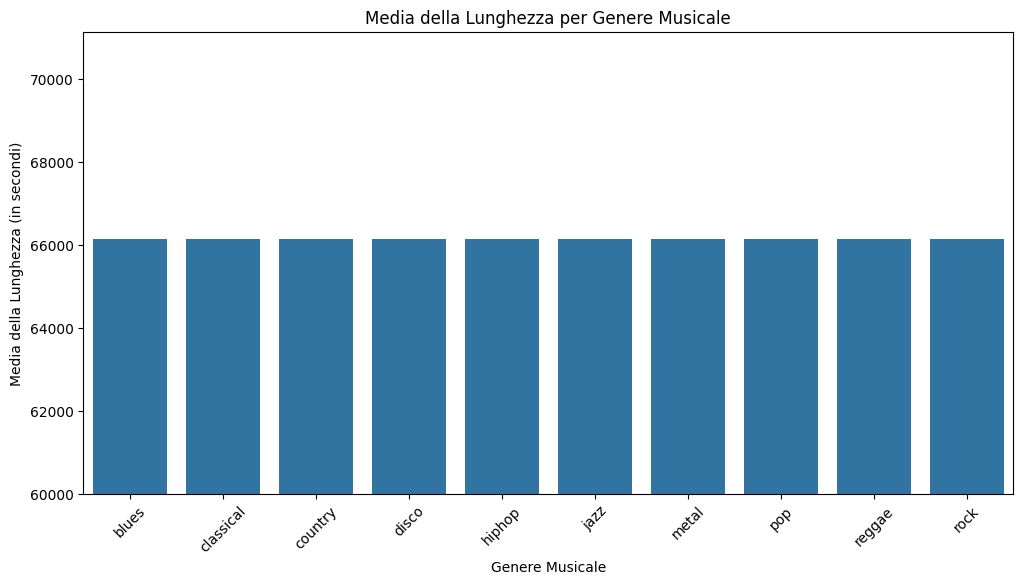

In [14]:
mean_length_by_genre = music_data_3sec.groupby('label')['length'].mean()

print(music_data_3sec.groupby('label')['length'].mean())

# Visualizzo la media della lunghezza per ogni genere musicale
plt.figure(figsize=(12, 6))
sns.barplot(x=mean_length_by_genre.index, y=mean_length_by_genre.values)
plt.xlabel("Genere Musicale")
plt.ylabel("Media della Lunghezza (in secondi)")
plt.title("Media della Lunghezza per Genere Musicale")
plt.xticks(rotation=45)  # Ruota le etichette per una migliore leggibilità
plt.ylim(60000, mean_length_by_genre.max() + 5000)  # Imposta l'asse y da 500000

plt.show()

<H3> VARIANZA SPIEGATA 3 SECONDI

   Principal Component Most Influential Feature  Explained Variance Ratio
0                  PC1    spectral_centroid_var                  0.200550
1                  PC2               mfcc1_mean                  0.135427
2                  PC3              mfcc10_mean                  0.103453
3                  PC4               mfcc19_var                  0.065943
4                  PC5              mfcc16_mean                  0.043561
5                  PC6              harmony_var                  0.036772
6                  PC7               mfcc18_var                  0.029538
7                  PC8            perceptr_mean                  0.026538
8                  PC9             harmony_mean                  0.024887
9                 PC10              mfcc20_mean                  0.021422
10                PC11                    tempo                  0.018583
11                PC12                    tempo                  0.017399
12                PC13                

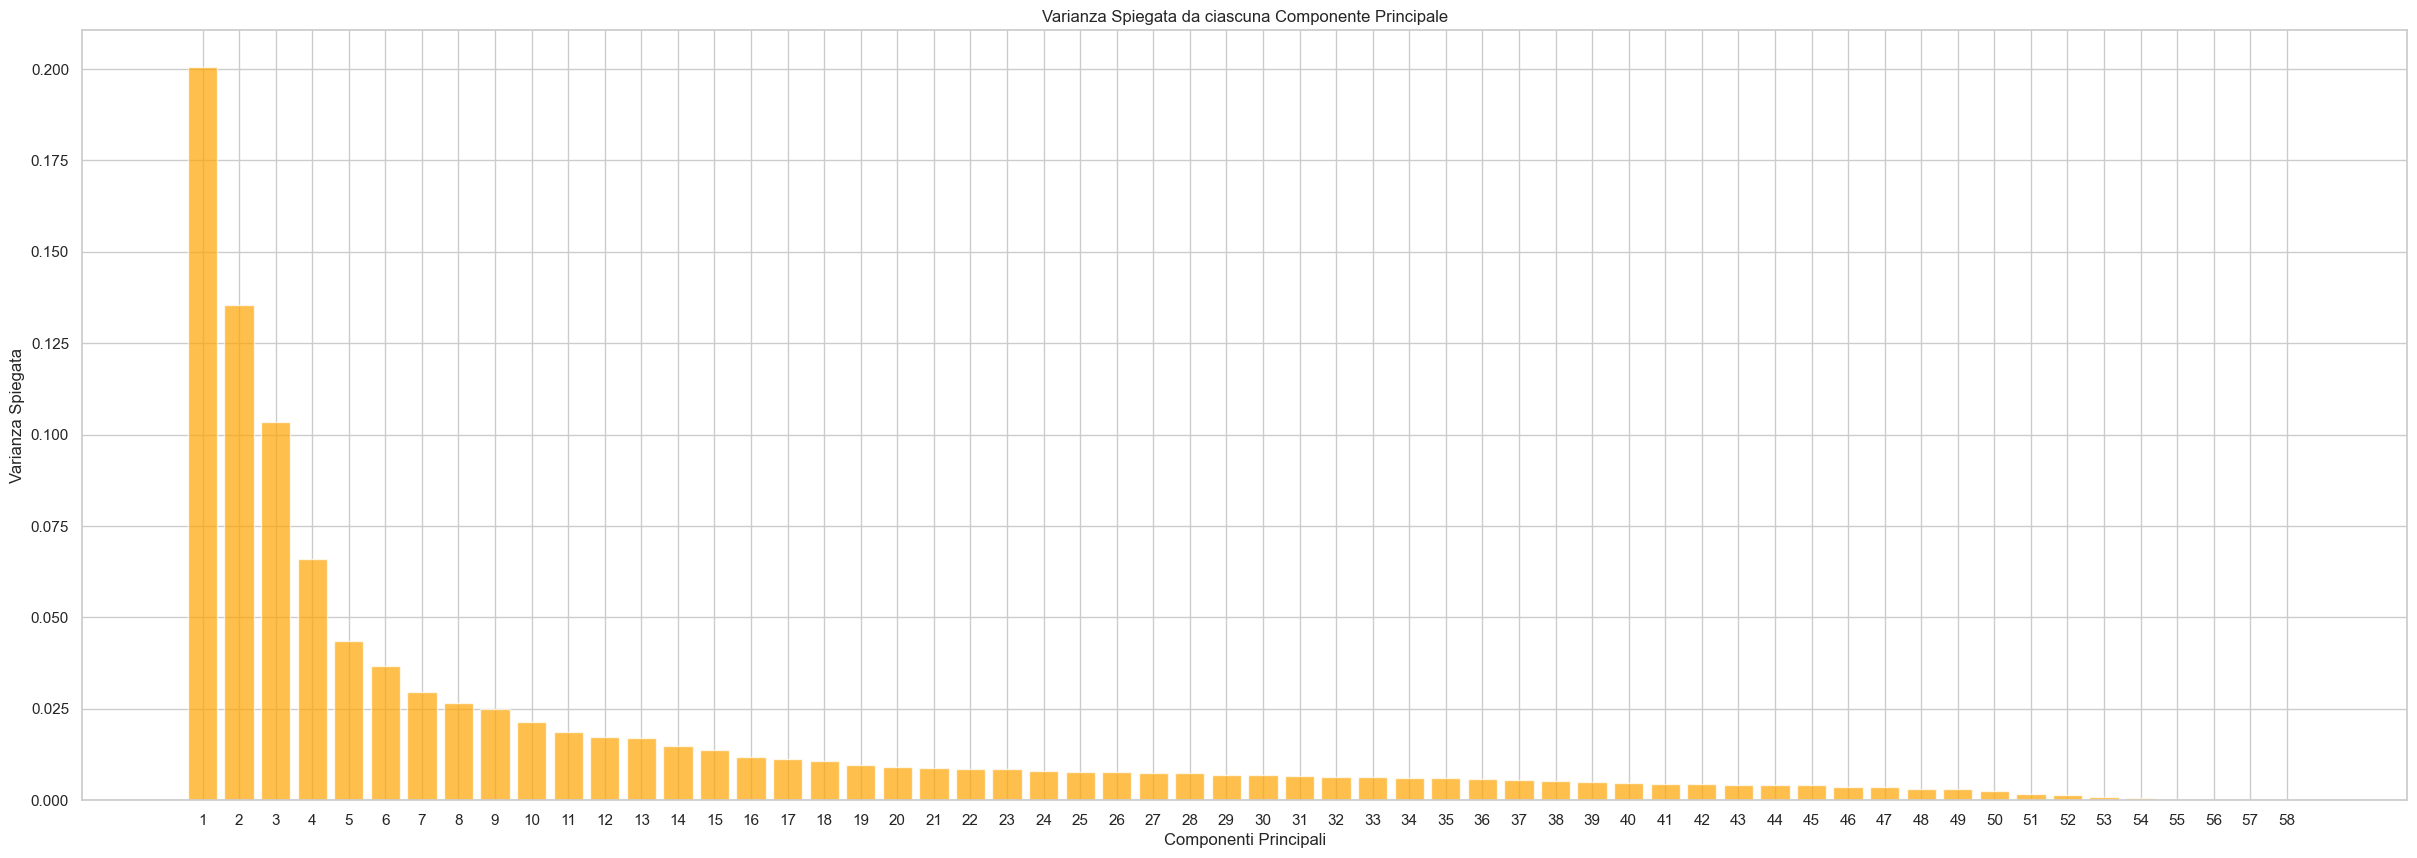

In [115]:
# Rimuovi le colonne non numeriche
X = music_data_3sec.drop(columns=['label', 'filename'])
feature_names = X.columns  # Salva i nomi delle colonne originali

# Normalizza i dati
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Applica PCA
pca = PCA()  # Per calcolare tutte le componenti principali
X_pca = pca.fit_transform(X_scaled)

# Identifica le feature più rappresentative per ogni componente principale
pc_feature_contributions = pd.DataFrame(pca.components_, columns=feature_names, index=[f'PC{i+1}' for i in range(len(pca.components_))])

# Trova la feature con il valore assoluto più alto per ogni PC
most_influential_features = pc_feature_contributions.abs().idxmax(axis=1)
explained_variances = pca.explained_variance_ratio_

# Combina i risultati in un DataFrame
pc_summary = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(pca.components_))],
    'Most Influential Feature': most_influential_features.values,
    'Explained Variance Ratio': explained_variances
})

print(pc_summary)

# HO 58 COMPONENTI PERCHE' NE SONO STATE TOLTE 2: FILE NAME E LABEL 

# Grafico della varianza spiegata da ciascuna componente principale
plt.figure(figsize=(30, 10))
plt.bar(range(1, len(explained_variances) + 1), explained_variances, alpha=0.7, color='orange')
plt.xlabel('Componenti Principali')
plt.ylabel('Varianza Spiegata')
plt.title('Varianza Spiegata da ciascuna Componente Principale')
plt.xticks(range(1, len(explained_variances) + 1))  # Aggiungi i numeri delle componenti sull'asse x
plt.show()




Numero di componenti per il 90% di varianza: 31
Varianza cumulativa spiegata: 90.67%


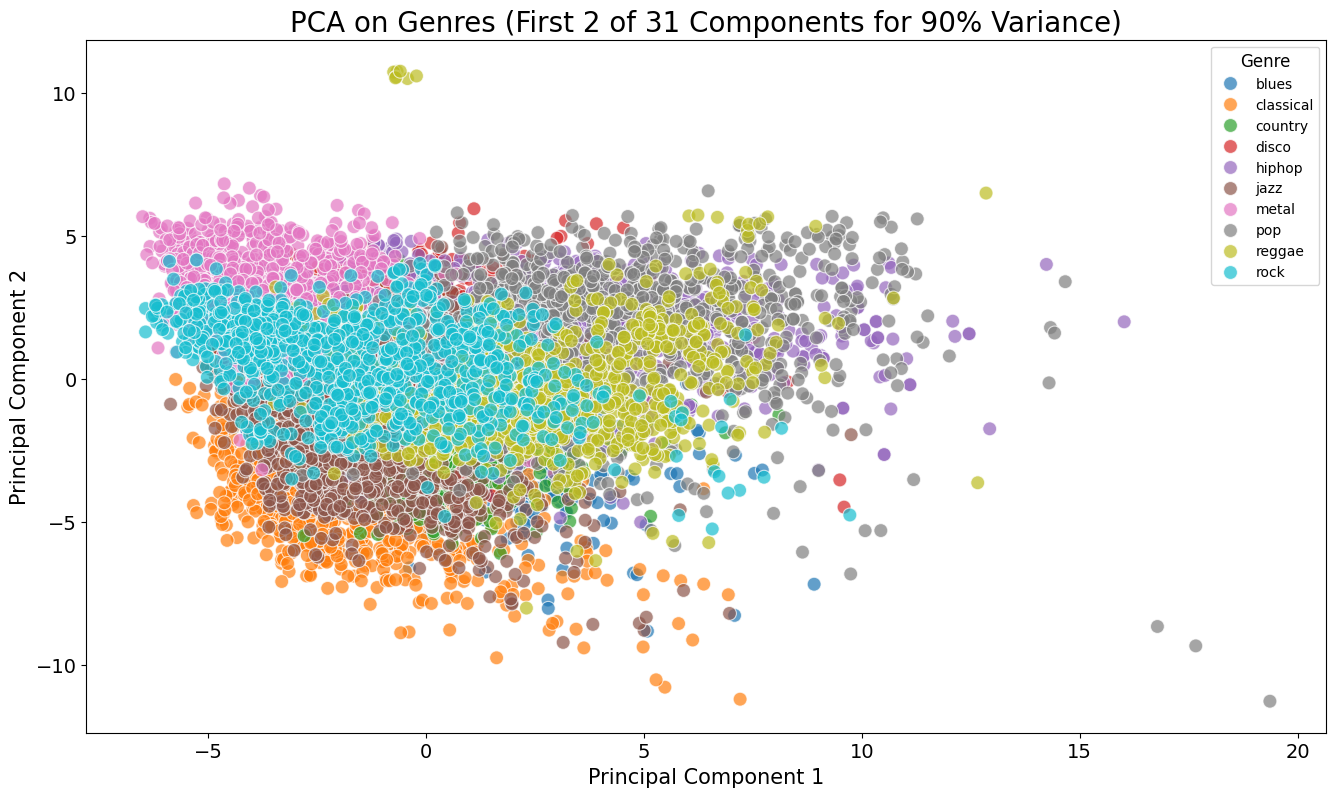

In [ ]:
data = music_data_3sec.iloc[:, 1:]
y = data['label']
X = data.loc[:, data.columns != 'label']

# Normalizzazione
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=data.columns[1:])  # Escludi la colonna 'label'

# PCA per il 90% della varianza
pca = PCA(n_components=0.90)  # Imposta la soglia di varianza al 90%
principalComponents = pca.fit_transform(X)

# Numero di componenti selezionati automaticamente
n_components = pca.n_components_
print(f"Numero di componenti per il 90% di varianza: {n_components}")
print(f"Varianza cumulativa spiegata: {sum(pca.explained_variance_ratio_):.2%}")

# DataFrame con le prime due componenti (PC1 e PC2) per la visualizzazione
principalDf = pd.DataFrame(
    data=principalComponents[:, :2],  # Prendi solo le prime due componenti
    columns=['pc1', 'pc2']
)

# Aggiungi le label
finalDf = pd.concat([principalDf, y], axis=1)

# Plot
plt.figure(figsize=(16, 9))
sns.scatterplot(x="pc1", y="pc2", data=finalDf, hue="label", alpha=0.7, s=100)
plt.title(f'PCA on Genres (First 2 of {n_components} Components for 90% Variance)', fontsize=20)
plt.xlabel("Principal Component 1", fontsize=15)
plt.ylabel("Principal Component 2", fontsize=15)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(title='Genre', title_fontsize=12, fontsize=10)
plt.show()